In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans 


In [3]:
df = pd.read_csv("../Dataset/fraud_detection.csv")

In [4]:
df.head()

,Transaction_ID,Amount,Hour,Merchant_Category,Distance_km,Device_Score,Daily_Transactions,Failed_Logins,International,Weekend,Account_Age_Months,Fraud
0,100001,78534.08,21,Shopping,222.6,17,23,5,0,0,7,1
1,100002,14997.97,19,Grocery,2167.4,1,13,5,0,0,33,1
2,100003,87342.26,5,Shopping,3536.5,26,22,9,1,0,1,1
3,100004,36955.20,11,Travel,1155.0,21,14,3,1,0,7,1
4,100005,97819.75,9,Shopping,3675.7,34,15,8,0,0,36,1


In [6]:
df.shape

(50000, 12)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      50000 non-null  int64  
 1   Amount              50000 non-null  float64
 2   Hour                50000 non-null  int64  
 3   Merchant_Category   50000 non-null  str    
 4   Distance_km         50000 non-null  float64
 5   Device_Score        50000 non-null  int64  
 6   Daily_Transactions  50000 non-null  int64  
 7   Failed_Logins       50000 non-null  int64  
 8   International       50000 non-null  int64  
 9   Weekend             50000 non-null  int64  
 10  Account_Age_Months  50000 non-null  int64  
 11  Fraud               50000 non-null  int64  
dtypes: float64(2), int64(9), str(1)
memory usage: 4.6 MB


In [8]:
df.isnull().sum()

Transaction_ID        0
Amount                0
Hour                  0
Merchant_Category     0
Distance_km           0
Device_Score          0
Daily_Transactions    0
Failed_Logins         0
International         0
Weekend               0
Account_Age_Months    0
Fraud                 0
dtype: int64

In [9]:
df.describe()

,Transaction_ID,Amount,Hour,Distance_km,Device_Score,Daily_Transactions,Failed_Logins,International,Weekend,Account_Age_Months,Fraud
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,16621.100262,11.424280,589.690858,68.077040,8.427300,1.374440,0.140860,0.287380,78.049880,0.200000
std,14433.901067,27611.995126,6.934876,1165.882432,26.793621,9.164027,2.616106,0.347881,0.452545,54.392161,0.400004
min,100001.000000,10.810000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,112500.750000,3147.240000,5.000000,62.300000,62.000000,3.000000,0.000000,0.000000,0.000000,27.000000,0.000000
50%,125000.500000,6264.135000,11.000000,124.900000,75.000000,5.000000,0.000000,0.000000,0.000000,71.000000,0.000000
75%,137500.250000,9293.837500,17.000000,186.400000,88.000000,8.000000,1.000000,0.000000,1.000000,126.000000,0.000000
max,150000.000000,119997.540000,23.000000,4999.000000,100.000000,40.000000,10.000000,1.000000,1.000000,180.000000,1.000000


<Axes: xlabel='Fraud', ylabel='count'>

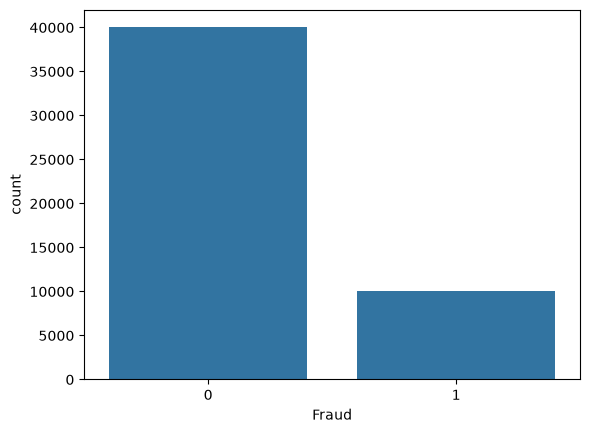

In [10]:
sns.countplot(x='Fraud',data=df)

In [16]:
X = df.drop(columns=["Transaction_ID", "Merchant_Category", "Fraud"])

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
# Elbow Method
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

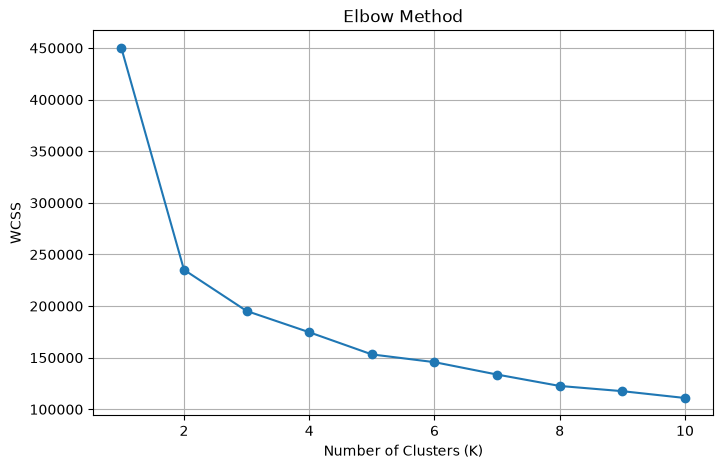

In [19]:
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [20]:
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    print(f"K = {k}: {score:.4f}")

K = 2: 0.5408
K = 3: 0.3246
K = 4: 0.3084
K = 5: 0.2672
K = 6: 0.2626
K = 7: 0.2596
K = 8: 0.2681
K = 9: 0.2635
K = 10: 0.2667


In [21]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

In [22]:
import pandas as pd

print(pd.crosstab(df["Cluster"], df["Fraud"]))

Fraud        0     1
Cluster             
0        40000    40
1            0  9960


## Cluster Evaluation (Confusion Table)

Since K-Means is an **unsupervised learning algorithm**, it does not use the `Fraud` column during training. After clustering, the actual fraud labels are used only to evaluate how well the clusters correspond to genuine and fraudulent transactions.

### Confusion Table

| Cluster | Genuine Transactions (Fraud = 0) | Fraud Transactions (Fraud = 1) |
|---------|----------------------------------:|--------------------------------:|
| **0** | **40,000** | **40** |
| **1** | **0** | **9,960** |

### Interpretation

- **Cluster 0** contains **40,000 genuine transactions** and only **40 fraudulent transactions**, indicating that it primarily represents legitimate transactions.
- **Cluster 1** contains **9,960 fraudulent transactions** and **no genuine transactions**, indicating that it primarily represents fraudulent transactions.

### Performance Summary

- **Total Genuine Transactions:** 40,000
- **Correctly Clustered Genuine Transactions:** 40,000 (**100%**)

- **Total Fraudulent Transactions:** 10,000
- **Correctly Clustered Fraudulent Transactions:** 9,960 (**99.6%**)

### Conclusion

The confusion table shows that the K-Means algorithm successfully separated the synthetic transaction data into two meaningful clusters. One cluster predominantly contains genuine transactions, while the other predominantly contains fraudulent transactions. The small number of misclassified fraud cases (40 transactions) indicates that the clusters are well separated, resulting in excellent clustering performance on this synthetic dataset.

In [23]:
pickle.dump(kmeans, open("../model/kmeans_model.pkl", "wb"))
pickle.dump(scaler, open("../model/scaler.pkl", "wb"))